# Netflix Content EDA

## Introduction

This project explores the Netflix Movies and TV Shows dataset to identify patterns in the platform's catalog.

The analysis focuses on:

- How old content was when it was added
- Rating patterns across movies and TV shows
- Countries contributing fresher or older content
- Genre distribution across content types
- Monthly patterns in content additions

The project is intended as a practical exploratory data analysis exercise using Python, Pandas, Matplotlib, and Seaborn.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Load the Dataset

In [3]:
df = pd.read_csv(r"E:\clg\IQ\netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 8807
Columns: 12


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [6]:
df.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## 2. Data Cleaning

Several categorical columns contain missing values. For this analysis, missing categorical values are represented as `"Unknown"` so that rows are retained for later exploration.

In [8]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")

df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

df.isnull().sum().sort_values(ascending=False)

date_added      98
duration         3
show_id          0
type             0
director         0
title            0
country          0
cast             0
release_year     0
rating           0
listed_in        0
description      0
dtype: int64

## 3. Feature Engineering

In [9]:
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month
df["month_name"] = df["date_added"].dt.month_name()

df["year_gap_at_addition"] = df["year_added"] - df["release_year"]

df[["title", "type", "release_year", "year_added", "year_gap_at_addition"]].head(10)

,title,type,release_year,year_added,year_gap_at_addition
0,Dick Johnson Is Dead,Movie,2020,2021.0,1.0
1,Blood & Water,TV Show,2021,2021.0,0.0
2,Ganglands,TV Show,2021,2021.0,0.0
3,Jailbirds New Orleans,TV Show,2021,2021.0,0.0
4,Kota Factory,TV Show,2021,2021.0,0.0
5,Midnight Mass,TV Show,2021,2021.0,0.0
6,My Little Pony: A New Generation,Movie,2021,2021.0,0.0
7,Sankofa,Movie,1993,2021.0,28.0
8,The Great British Baking Show,TV Show,2021,2021.0,0.0
9,The Starling,Movie,2021,2021.0,0.0


## 4. Content Age at Addition

### Question
How old was content when it was added to Netflix?

In [10]:
fresh_df = df[df["year_gap_at_addition"].notna()].copy()
fresh_df = fresh_df[fresh_df["year_gap_at_addition"] >= 0]

fresh_df["year_gap_at_addition"].describe()

count    8695.000000
mean        4.700403
std         8.796060
min         0.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: year_gap_at_addition, dtype: float64

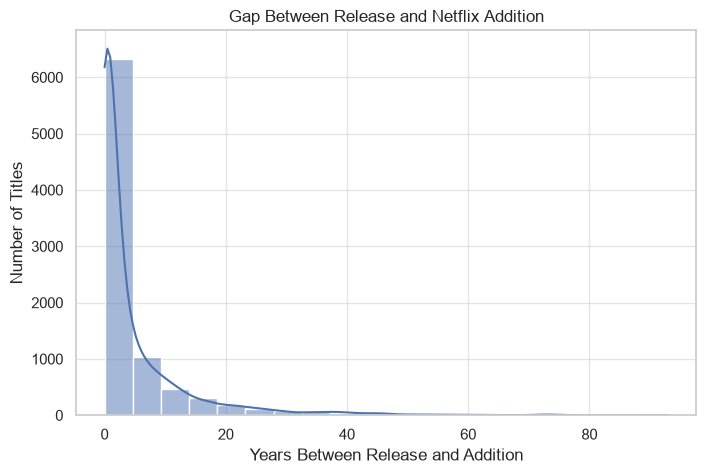

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(fresh_df["year_gap_at_addition"], bins=20, kde=True)
plt.title("Gap Between Release and Netflix Addition")
plt.xlabel("Years Between Release and Addition")
plt.ylabel("Number of Titles")
plt.show()

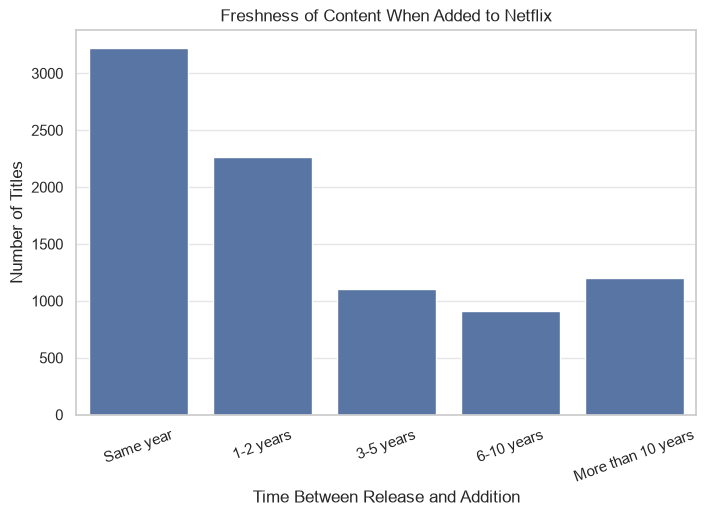

In [12]:
fresh_df["freshness_group"] = pd.cut(
    fresh_df["year_gap_at_addition"],
    bins=[-1, 0, 2, 5, 10, 100],
    labels=["Same year", "1-2 years", "3-5 years", "6-10 years", "More than 10 years"]
)

plt.figure(figsize=(8, 5))
sns.countplot(
    x="freshness_group",
    data=fresh_df,
    order=["Same year", "1-2 years", "3-5 years", "6-10 years", "More than 10 years"]
)
plt.title("Freshness of Content When Added to Netflix")
plt.xlabel("Time Between Release and Addition")
plt.ylabel("Number of Titles")
plt.xticks(rotation=20)
plt.show()

### Observation

The distribution shows that many titles were added within a relatively small number of years after their original release. The dataset also contains older titles that were added several years after release.

This analysis describes the dataset and should not be interpreted as a complete representation of Netflix's current catalog or acquisition strategy.

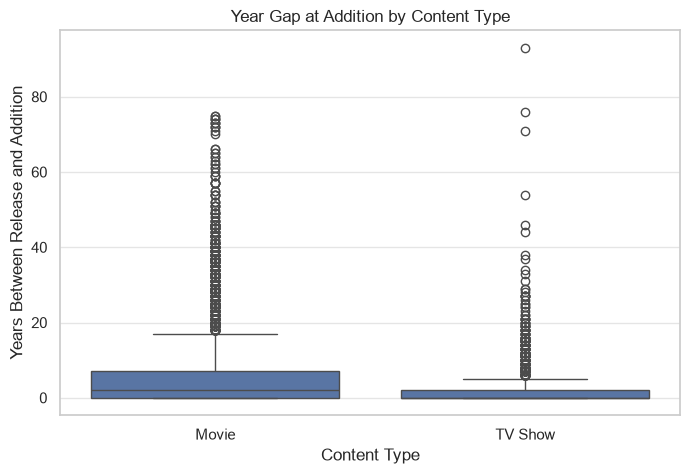

,mean,median
type,,
Movie,5.729972,2.0
TV Show,2.241231,0.0


In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="type", y="year_gap_at_addition", data=fresh_df)
plt.title("Year Gap at Addition by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Years Between Release and Addition")
plt.show()

fresh_df.groupby("type")["year_gap_at_addition"].agg(["mean", "median"])

### Observation

The mean and median gaps allow movies and TV shows to be compared using two different measures of central tendency. The median is useful here because it is less affected by unusually old titles.

## 5. Rating Patterns

### Question
Do movies and TV shows follow different rating patterns?

In [14]:
df["rating"].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

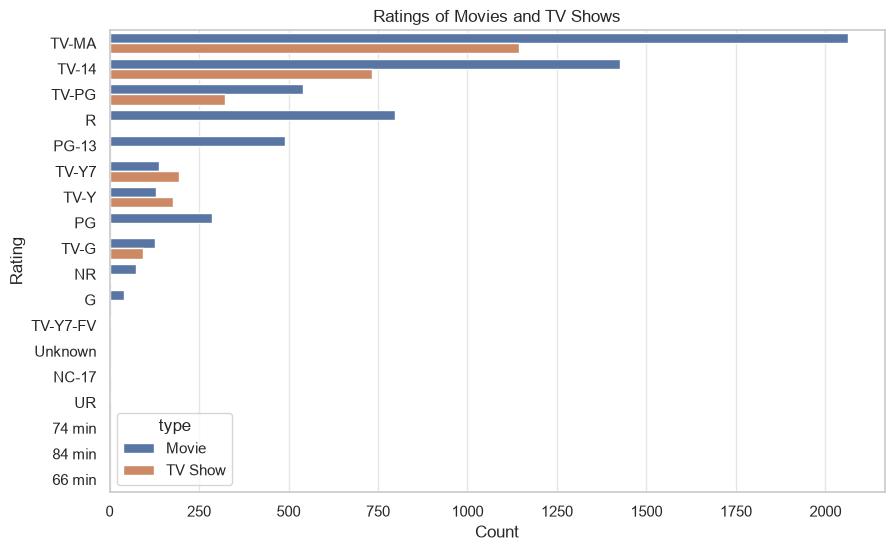

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    y="rating",
    hue="type",
    order=df["rating"].value_counts().index
)
plt.title("Ratings of Movies and TV Shows")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.show()

In [16]:
rating_type_table = pd.crosstab(df["rating"], df["type"])
rating_type_table

type,Movie,TV Show
rating,,
66 min,1,0
74 min,1,0
84 min,1,0
G,41,0
NC-17,3,0
NR,75,5
PG,287,0
PG-13,490,0
R,797,2


In [17]:
rating_type_percent = pd.crosstab(
    df["rating"],
    df["type"],
    normalize="index"
) * 100

rating_type_percent

type,Movie,TV Show
rating,,
66 min,100.000000,0.000000
74 min,100.000000,0.000000
84 min,100.000000,0.000000
G,100.000000,0.000000
NC-17,100.000000,0.000000
NR,93.750000,6.250000
PG,100.000000,0.000000
PG-13,100.000000,0.000000
R,99.749687,0.250313


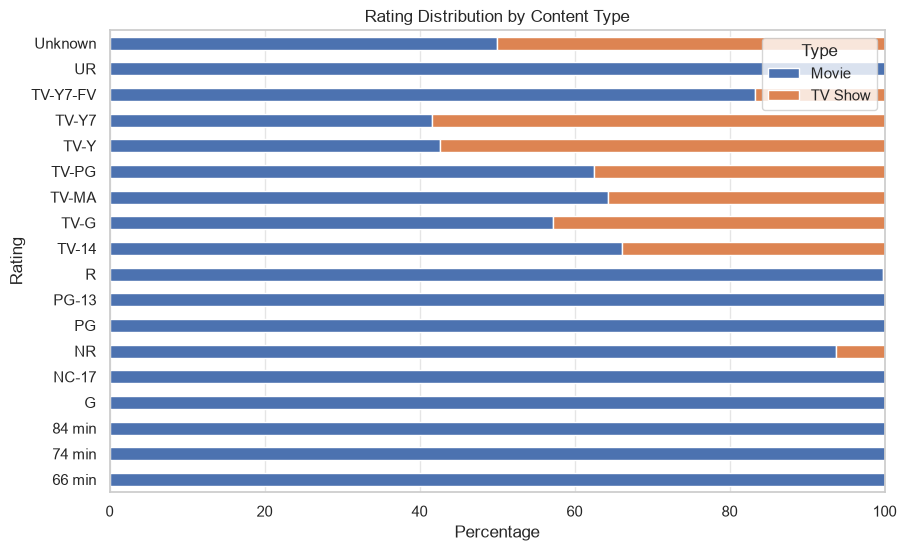

In [18]:
rating_type_percent.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Rating Distribution by Content Type")
plt.xlabel("Percentage")
plt.ylabel("Rating")
plt.legend(title="Type")
plt.show()

### Observation

The rating distribution differs across movies and TV shows. Some rating categories are strongly associated with one content type, while others appear across both types.

## 6. Country-Level Content Freshness

### Question
Which countries contribute relatively fresher content, and which contribute older content?

Because the `country` column can contain multiple countries for a single title, the values are split and expanded before aggregation.

In [19]:
country_df = fresh_df[fresh_df["country"] != "Unknown"].copy()

country_df["country"] = country_df["country"].str.split(", ")
country_df = country_df.explode("country")

country_df["country"].value_counts().head(10)

country
United States     3631
India             1045
United Kingdom     784
Canada             429
France             388
Japan              313
Spain              228
South Korea        226
Germany            225
Mexico             168
Name: count, dtype: int64

In [20]:
top_countries = country_df["country"].value_counts().head(10).index
top_country_df = country_df[country_df["country"].isin(top_countries)]

country_gap_mean = (
    top_country_df.groupby("country")["year_gap_at_addition"]
    .mean()
    .sort_values()
)

country_gap_mean

country
Spain             1.710526
South Korea       1.787611
Mexico            2.910714
Canada            3.766900
United Kingdom    4.947704
Japan             4.968051
France            5.012887
Germany           5.320000
United States     5.714128
India             6.691866
Name: year_gap_at_addition, dtype: float64

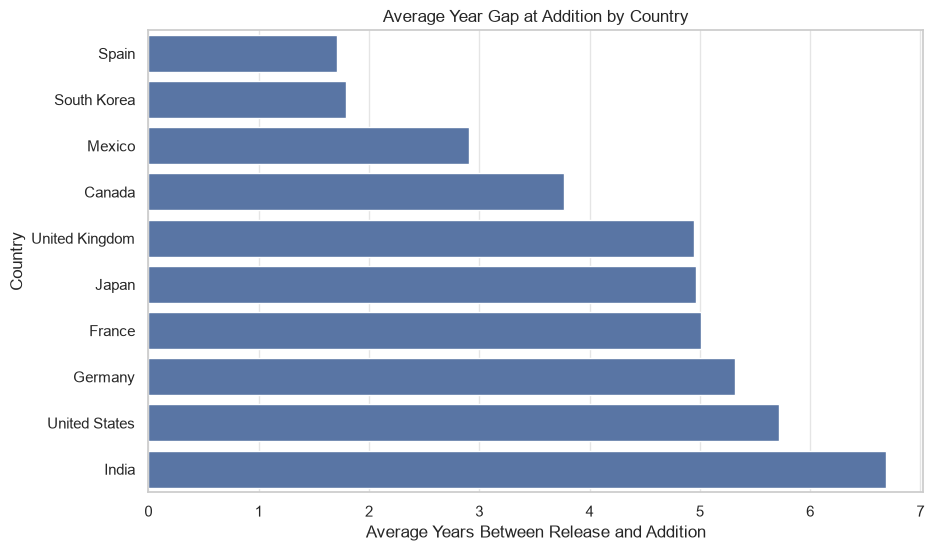

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(x=country_gap_mean.values, y=country_gap_mean.index)
plt.title("Average Year Gap at Addition by Country")
plt.xlabel("Average Years Between Release and Addition")
plt.ylabel("Country")
plt.show()

In [22]:
country_gap_median = (
    top_country_df.groupby("country")["year_gap_at_addition"]
    .median()
    .sort_values()
)

country_gap_median

country
Mexico            0.0
South Korea       1.0
Spain             1.0
United States     1.0
France            2.0
Germany           2.0
Japan             2.0
Canada            2.0
United Kingdom    2.0
India             3.0
Name: year_gap_at_addition, dtype: float64

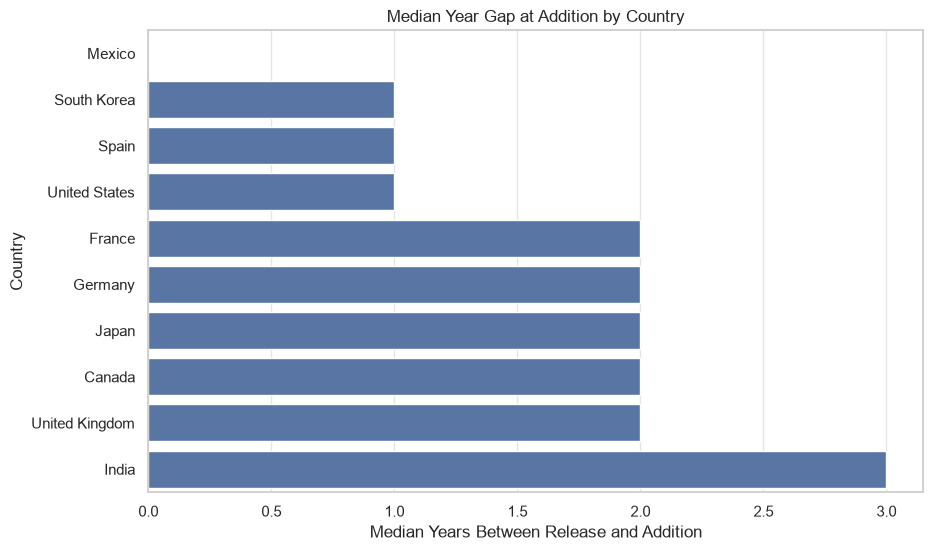

In [23]:
plt.figure(figsize=(10, 6))
sns.barplot(x=country_gap_median.values, y=country_gap_median.index)
plt.title("Median Year Gap at Addition by Country")
plt.xlabel("Median Years Between Release and Addition")
plt.ylabel("Country")
plt.show()

In [24]:
country_summary = (
    top_country_df.groupby("country")
    .agg(
        total_titles=("title", "count"),
        avg_gap=("year_gap_at_addition", "mean"),
        median_gap=("year_gap_at_addition", "median")
    )
    .sort_values("total_titles", ascending=False)
)

country_summary

,total_titles,avg_gap,median_gap
country,,,
United States,3631,5.714128,1.0
India,1045,6.691866,3.0
United Kingdom,784,4.947704,2.0
Canada,429,3.766900,2.0
France,388,5.012887,2.0
Japan,313,4.968051,2.0
Spain,228,1.710526,1.0
South Korea,226,1.787611,1.0
Germany,225,5.320000,2.0


### Observation

Countries differ in the typical gap between a title's release and its addition to the dataset. Both mean and median are shown because the distribution of release-to-addition gaps can vary between countries.

The comparison should be interpreted alongside the number of titles represented for each country.

## 7. Genre Distribution

### Question
Which genres are more movie-dominant and which are more TV-show-dominant?

The `listed_in` column can contain multiple genres for one title, so it is split and exploded before counting.

In [25]:
genre_df = df.copy()

genre_df["genre"] = genre_df["listed_in"].str.split(", ")
genre_df = genre_df.explode("genre")

genre_df["genre"].value_counts().head(10)

genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

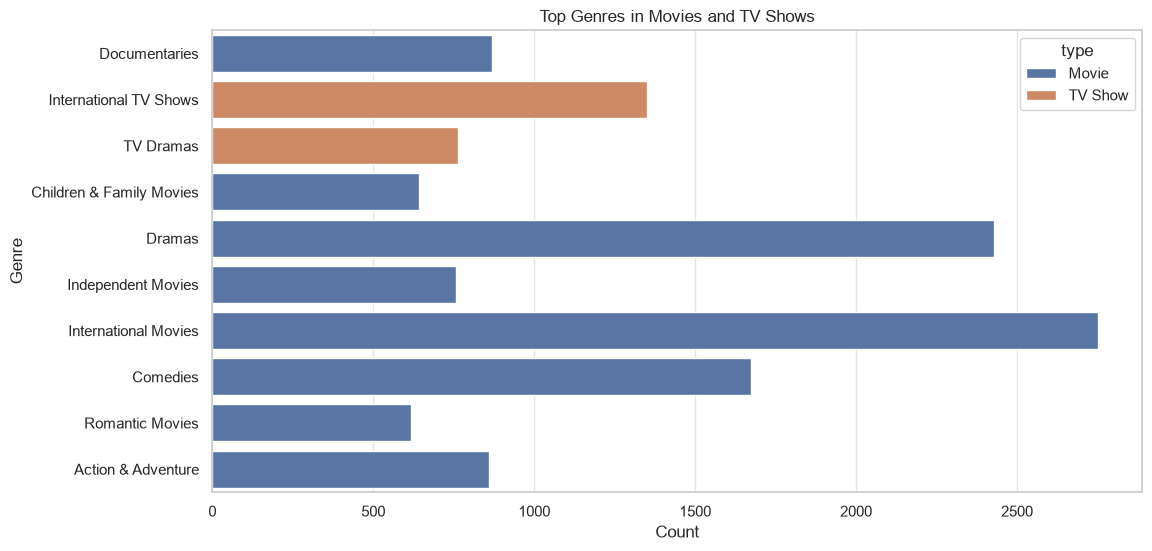

In [26]:
top_genres = genre_df["genre"].value_counts().head(10).index
top_genre_df = genre_df[genre_df["genre"].isin(top_genres)]

plt.figure(figsize=(12, 6))
sns.countplot(
    data=top_genre_df,
    y="genre",
    hue="type"
)
plt.title("Top Genres in Movies and TV Shows")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

### Observation

The genre distribution shows the most frequently represented categories in the dataset. Comparing the counts by content type highlights genres with a stronger movie or TV-show presence.

## 8. Monthly Content Additions

### Question
Are some months more active than others for content additions?

In [27]:
monthly_additions = df["month_added"].value_counts().sort_index()

monthly_additions

month_added
1.0     727
2.0     557
3.0     734
4.0     759
5.0     626
6.0     724
7.0     819
8.0     749
9.0     765
10.0    755
11.0    697
12.0    797
Name: count, dtype: int64

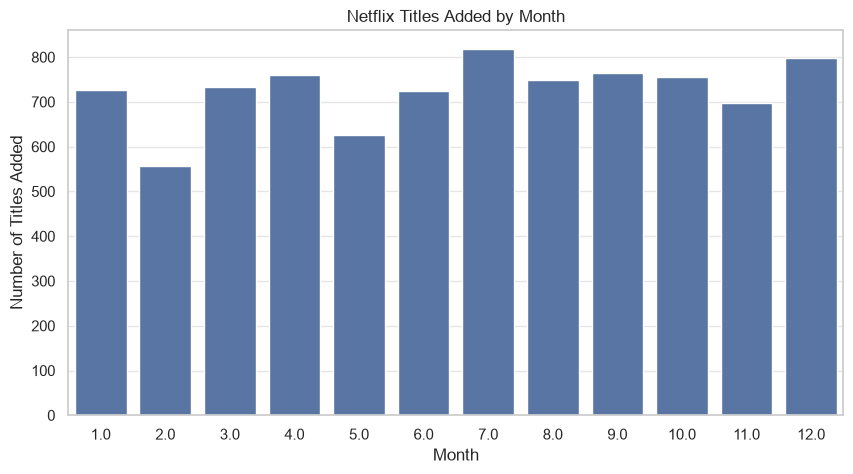

In [28]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=monthly_additions.index,
    y=monthly_additions.values
)
plt.title("Netflix Titles Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles Added")
plt.show()

### Observation

The monthly distribution shows that the number of titles added is not necessarily uniform throughout the year. The chart can be used to identify months with relatively higher or lower numbers of additions in this dataset.

## 9. Key Findings

- The dataset contains both movies and TV shows with different rating distributions.
- Many titles were added relatively close to their original release year, while older titles are also represented.
- Country-level analysis shows differences in the release-to-addition gap.
- Genre distributions vary between movies and TV shows.
- The number of titles added varies across months.

These findings describe patterns in the provided dataset rather than Netflix's complete current catalog.

## 10. Limitations

- The analysis is based on the provided Netflix titles dataset and may not represent the current Netflix catalog.
- Missing values are present in several columns.
- Country and genre fields can contain multiple values for a single title.
- Country comparisons can be influenced by differences in the number of titles represented.
- The analysis identifies patterns and relationships in the dataset but does not establish causal relationships.

## 11. Conclusion

This project used exploratory data analysis to investigate patterns in Netflix movies and TV shows.

The workflow included data inspection, missing-value handling, datetime conversion, feature engineering, aggregation, processing multi-valued categorical fields, and visualization using Pandas, Matplotlib, and Seaborn.

The project provided practical experience in turning a raw dataset into a structured analysis and communicating observations from the resulting data.